In [1]:
# Cell for loading environment variables from config.py,
# which is located one directory above this notebook.
import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)

from config import set_environment
set_environment()

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate

In [3]:
# llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
llm = ChatOpenAI(model="gpt-4")

# ReACT example

Let's deep dive into the ReACT pattern and implement it ourselves. We will mock tools as simple Python functions (without actual implementation) for now:

In [4]:
import math 

def mocked_google_search(query: str) -> str:
    print(f"CALLED GOOGLE_SEARCH with query: {query}")
    return "Donald Trump is the current president of USA and he's 78 years old."

def mocked_calculator(expression: str) -> str:
    print(f"CALLED CALCULATOR with expression={expression}")
    if "sqrt" in expression:
        return math.sqrt(78*132)
    return 78 * 132

Let's define schemas for our tools and pass them to an LLM:

In [5]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

calculator_tool = {
    "type": "function",
    "function": {
        "name": "calculator",
        "description": "Computes mathematical expressions",
        "parameters": {
            "type": "object",
            "properties": {
                "expression": {
                    "type": "string",
                    "title": "expression",
                    "description": "A mathematical expression to be evaluated by a calculator",
                }
            },
            "required": ["expression"]
        }
    }
}

search_tool = {
    "type": "function",
    "function": {
        "name": "google_search",
        "description": "Returns about common facts, fresh events and news from Google Search engine based on a query.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "title": "search_query",
                    "description": "Search query to be sent to the search engine",
                }
            },
            "required": ["query"]
        }
    }
}

system_prompt = (
    "Always use a calculator for mathematical computations, and use Google Search "
    "for information about common facts, fresh events and news. Do not assume anything, keep in "
    "mind that things are changing and always "
    "check yourself with external sources if possible."
)

from langchain_core.messages import SystemMessage

prompt = ChatPromptTemplate.from_messages(
    [SystemMessage(system_prompt), MessagesPlaceholder(variable_name="messages")]
)

In [7]:
llm_with_tools = prompt | llm.bind_tools([search_tool, calculator_tool])

Now it's time to define the LangGraph workflow itself.

In [8]:
# Imports 
from langchain_core.messages import HumanMessage, ToolMessage
from langgraph.graph import START, END, MessagesState, StateGraph

def invoke_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

def call_tools(state: MessagesState):
    last_message = state["messages"][-1]
    tools_calls = last_message.tool_calls

    new_messages = []

    for tool_call in tools_calls:
        if tool_call["name"] == "google_search":
            tool_result = mocked_google_search(**tool_call["args"])
            new_messages.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))
        elif tool_call["name"] == "calculator":
            tool_result = mocked_calculator(**tool_call["args"])
            new_messages.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))
        else:
            raise ValueError(f"Unknown tool: {tool_call['name']}")

    return {"messages": new_messages}

def should_run_tools(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "call_tools"
    return END

And we can put everything together as following:

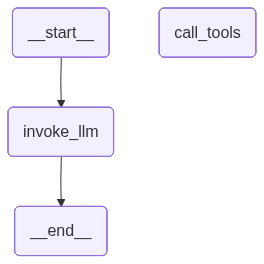

In [9]:
builder = StateGraph(MessagesState)

builder.add_node("invoke_llm", invoke_llm)
builder.add_node("call_tools", call_tools)

builder.add_edge(START, "invoke_llm")
builder.add_conditional_edges("invoke_llm", should_run_tools)
builder.add_edge("call_tools", "invoke_llm")

graph = builder.compile()

from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
question = "What is the square root of the current US president's age multiplied by 132?"

In [12]:
result = graph.invoke({"messages": [HumanMessage(content=question)]})
print(result["messages"][-1].content)

CALLED GOOGLE_SEARCH with query: current US president's age
CALLED CALCULATOR with expression=sqrt(78 * 132)
The square root of the current US president's age multiplied by 132 is approximately 101.47.


In [13]:
result

{'messages': [HumanMessage(content="What is the square root of the current US president's age multiplied by 132?", additional_kwargs={}, response_metadata={}, id='ac74438b-f97d-4370-b5dd-f86ef38203bc'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_5jXR8evPk5FJ3ZxcVT7kTszl', 'function': {'arguments': '{\n  "query": "current US president\'s age"\n}', 'name': 'google_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 160, 'total_tokens': 179, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-CwOy3dod53tzJjFfKQU5tAyTLy1NC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ba719-a6b3-7231-ad7a-90de6c5d2f0d-0', tool_calls=[{'

Now as you understand how it works under the hood, we can share good news with you. There's no need to implement it yourselves, you can use an customizable pre-built agent from LangGraph:

In [ ]:
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool


@tool("google_search")
def mocked_google_search_tool(query: str) -> str:
    """Returns about common facts, fresh events and news from Google Search engine based on a query."""
    return mocked_google_search(query)


@tool("calculator")
def mocked_calculator_tool(expression: str) -> str:
    """Computes mathematical expressions"""
    return mocked_calculator(expression)

agent = create_react_agent(
    model=llm,
    tools=[mocked_google_search_tool, mocked_calculator_tool],
    prompt=system_prompt,
)

In [22]:
result = agent.invoke({"messages": [HumanMessage(question)]})
print(result["messages"][-1].content)

CALLED GOOGLE_SEARCH with query: current US president's age
CALLED CALCULATOR with expression=sqrt(78*132)
The square root of the current US President's age multiplied by 132 is approximately 101.47.
